In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

with open("pokemon_data.json", "r") as file:
    data = json.load(file)
data_df = pd.DataFrame(data)
data_df_exploded = data_df.explode("types").rename(columns = {"types" : "type"})

In [2]:
pokemon_types = ["normal", "fire", "water", "grass", 
                 "electric", "ice", "fighting", "poison",
                 "ground", "flying", "psychic", "bug",
                 "rock", "ghost", "dragon", "dark",
                 "steel", "fairy"]



colours = {"normal" : "lightgray", "fire" : "red", 
           "water" : "dodgerblue", "grass" : "limegreen", 
            "electric" : "yellow", "ice" : "lightblue", 
            "fighting" : "maroon", "poison" : "purple",
            "ground" : "khaki", "flying" : "lightskyblue", 
            "psychic" : "fuchsia", "bug" : "yellowgreen",
            "rock" : "darkgoldenrod", "ghost" : "indigo", 
            "dragon" : "navy", "dark" : "grey",
            "steel" : "grey", "fairy" : "pink"}

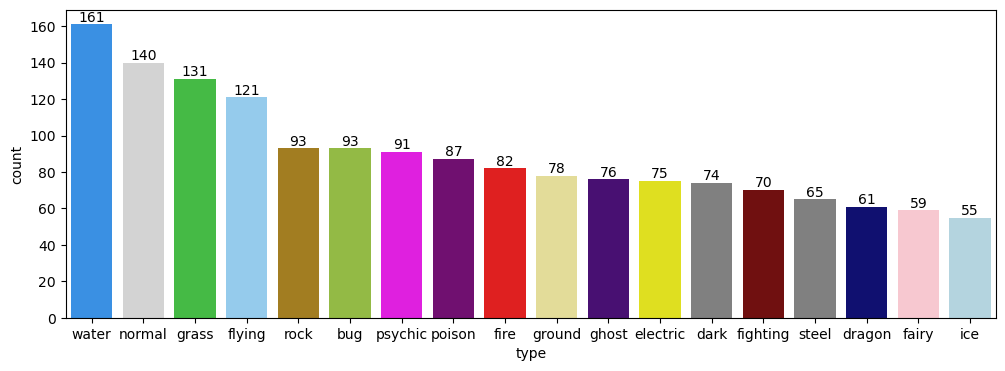

In [3]:
type_df = data_df_exploded.groupby("type")["name"].count().reset_index("type")
type_df = type_df.rename(columns = {"name" : "count"})

# resize graph to make x-axis labels legible
plt.figure(figsize=(12, 4))
graph = sns.barplot(data = type_df.sort_values("count", ascending = False), x = "type", y = "count", hue = "type", palette = colours, legend = False, errorbar = None)
# labelling bars
for container in graph.containers:
    graph.bar_label(container, fontsize = 10)


In [4]:
data_df["types"].str.len().value_counts()
#data_df["types"].head()
data_df["primary"] = data_df['types'].str[0]
data_df["secondary"] = data_df['types'].str[1].fillna('none')

In [5]:
type_table = pd.crosstab(data_df['primary'], data_df['secondary'])
type_table = type_table.reindex(index =pokemon_types, columns=pokemon_types + ['none'], fill_value=0)
type_table

secondary,normal,fire,water,grass,electric,ice,fighting,poison,ground,flying,psychic,bug,rock,ghost,dragon,dark,steel,fairy,none
primary,,,,,,,,,,,,,,,,,,,
normal,0,0,1,2,0,0,2,0,1,30,4,0,0,2,1,0,0,4,74
fire,2,0,0,0,0,0,6,1,2,4,3,2,3,5,2,1,0,0,36
water,0,0,0,3,2,4,2,3,9,7,6,2,5,4,3,7,1,3,75
grass,3,1,0,0,0,2,4,14,1,6,3,0,0,5,6,5,3,4,45
electric,2,1,1,3,0,2,2,3,1,5,1,0,0,1,2,2,4,1,32
ice,0,1,4,0,0,0,0,0,3,1,4,2,1,1,0,0,2,1,19
fighting,0,1,1,0,1,1,0,2,0,1,2,0,0,1,0,1,1,0,28
poison,2,2,3,0,0,0,2,0,4,3,2,1,0,0,2,5,0,1,16
ground,2,0,0,2,1,0,1,0,0,2,2,0,3,4,2,3,5,0,16


<Axes: xlabel='secondary', ylabel='primary'>

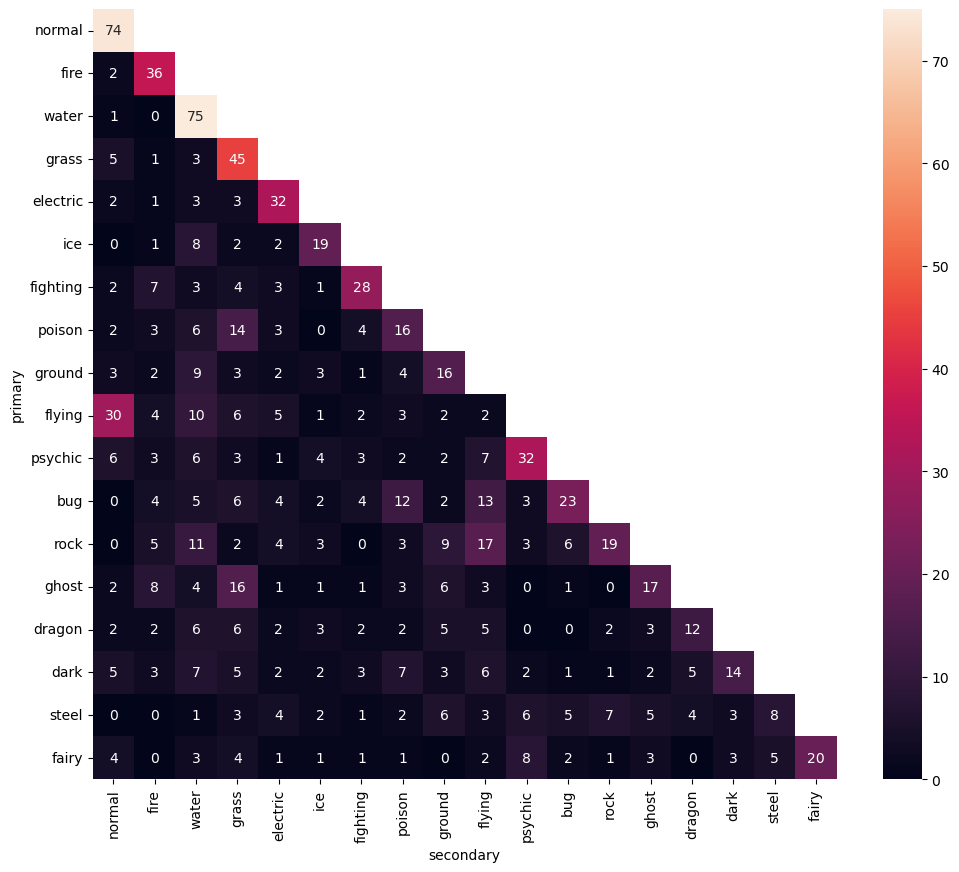

In [6]:
dual = type_table.drop(columns="none")
agnostic = dual + dual.T

for t in pokemon_types:
    agnostic.loc[t, t] = type_table.loc[t, "none"]

mask = np.triu(np.ones_like(agnostic, dtype=bool), k=1)

plt.figure(figsize=(12, 10))
sns.heatmap(agnostic, mask=mask, annot=True, fmt="d")

<Axes: xlabel='type', ylabel='speed'>

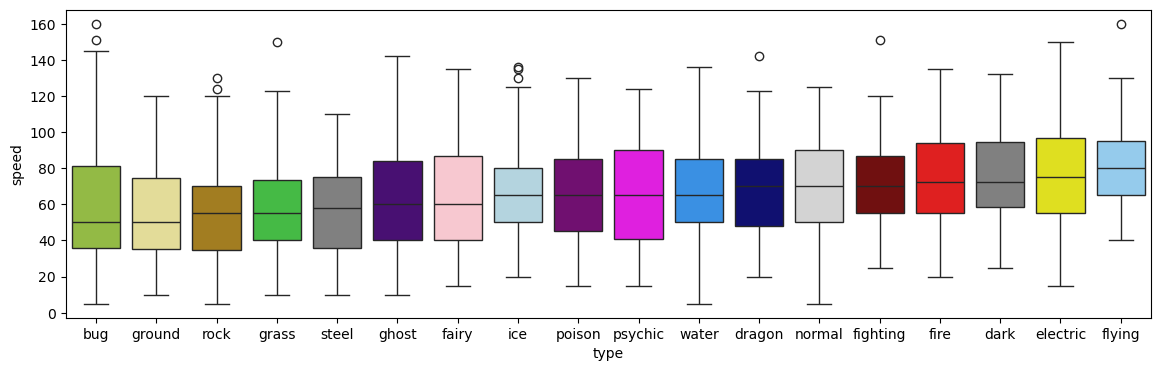

In [7]:
speed_order = data_df_exploded.groupby("type")["speed"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "speed", order=speed_order,
             hue="type", palette=colours, legend=False)

<Axes: xlabel='type', ylabel='hp'>

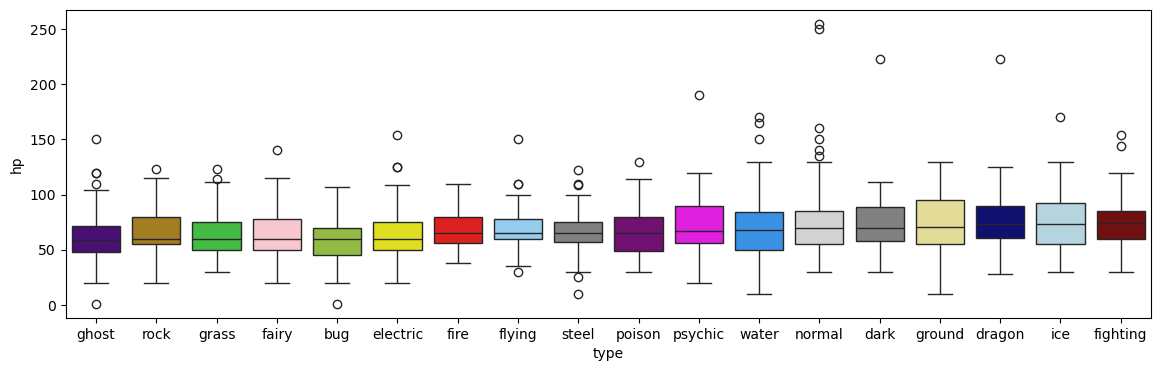

In [8]:
hp_order = data_df_exploded.groupby("type")["hp"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "hp", order=hp_order,
             hue="type", palette=colours, legend=False)

<Axes: xlabel='type', ylabel='attack'>

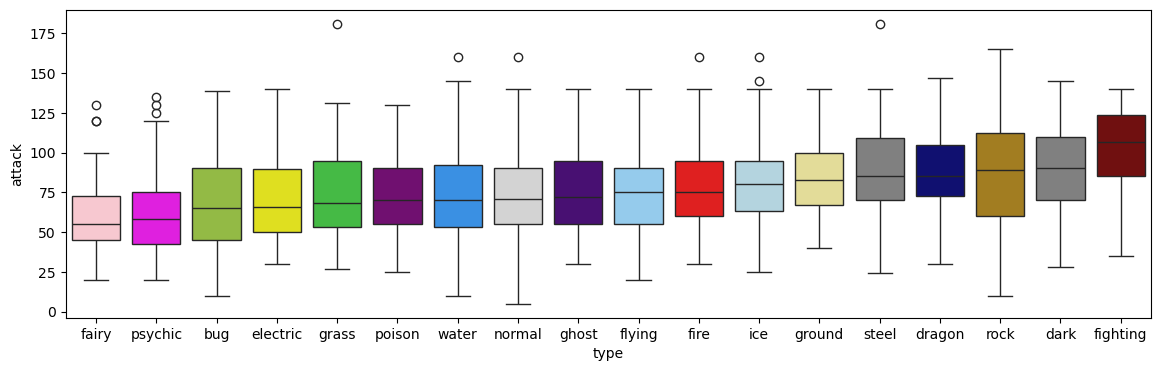

In [9]:
attack_order = data_df_exploded.groupby("type")["attack"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "attack", order=attack_order,
             hue="type", palette=colours, legend=False)

<Axes: xlabel='type', ylabel='special-attack'>

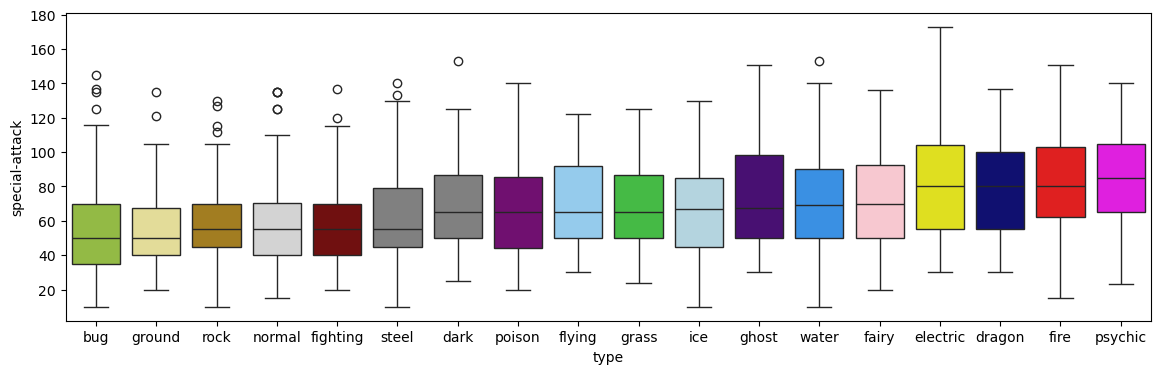

In [10]:
spattack_order = data_df_exploded.groupby("type")["special-attack"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "special-attack", order=spattack_order,
             hue="type", palette=colours, legend=False)

<Axes: xlabel='type', ylabel='defense'>

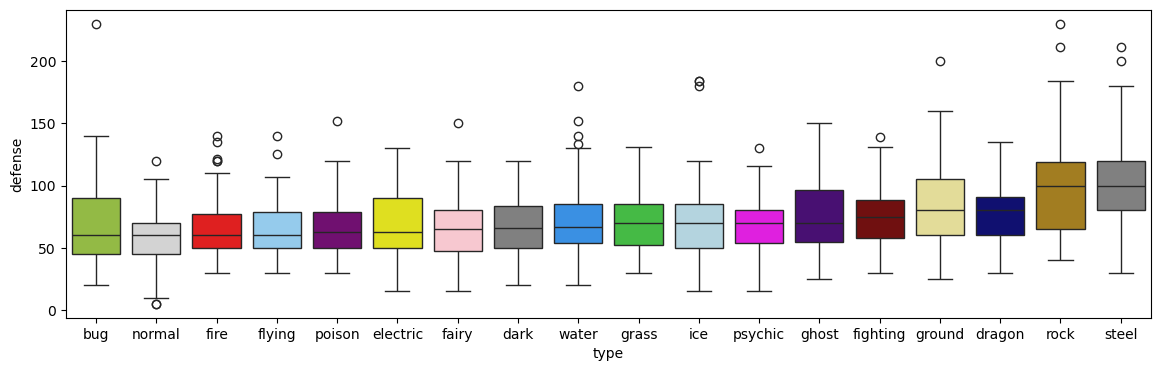

In [11]:
defense_order = data_df_exploded.groupby("type")["defense"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "defense", order=defense_order,
             hue="type", palette=colours, legend=False)

<Axes: xlabel='type', ylabel='special-defense'>

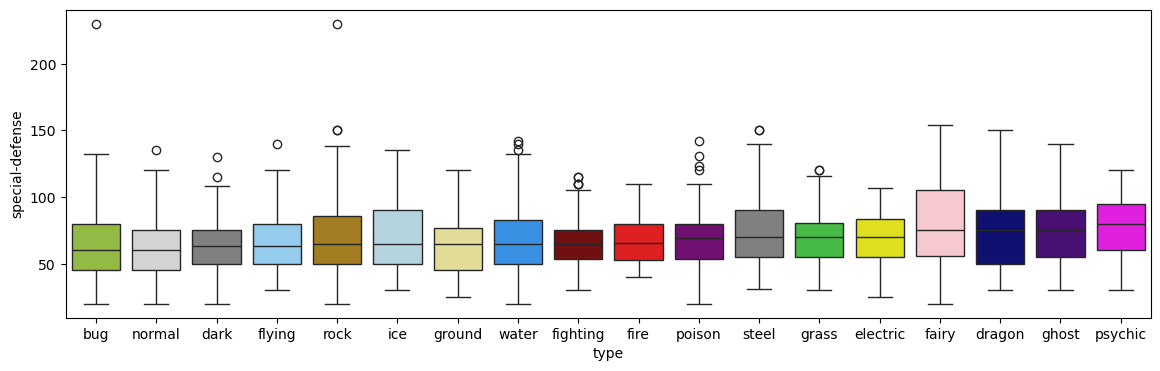

In [12]:
spdefense_order = data_df_exploded.groupby("type")["special-defense"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "special-defense", order=spdefense_order,
             hue="type", palette=colours, legend=False)

<Axes: xlabel='type', ylabel='base_stat_total'>

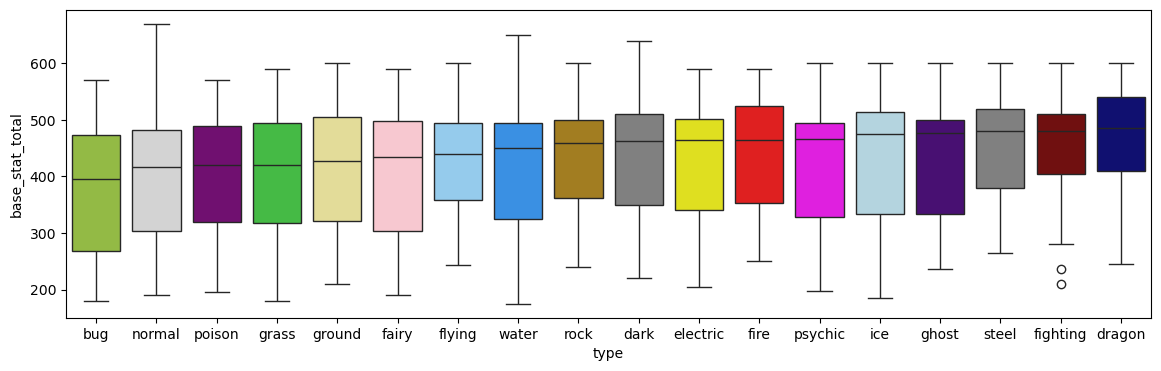

In [13]:
bst_order = data_df_exploded.groupby("type")["base_stat_total"].median().sort_values().index
plt.figure(figsize=(14,4))
sns.boxplot(data= data_df_exploded, x = "type", y= "base_stat_total", order=bst_order,
             hue="type", palette=colours, legend=False)